# Trip Points — Dataset Preparation & Spatial Exploration

**Purpose:** Convert the canonical quotes into actual trips (converted sessions only),
snap pickup and dropoff GPS points onto the road network, filter to the main connected
road component, and assign each trip's endpoints to a road network block. The output
is the input for the geofence optimiser.

**Input:** `data/processed/quotes_canonical.parquet`

**Output:** `data/processed/trips_assigned.csv`

Columns: `quote_id`, `sampled_revenue`, `pickup_block`, `dropoff_block`

**What is important for you in t his notebook?**

Here I just perform assignement of pick_up and drop_off points to blocks defined in a main connected componenet (resulting in 77.8 % of trips to be included of total number), no important analysiss and insights. The main steps are described in "All contents" section below.

**All Contents**

0. Imports & config
1. Build trip dataset — filter canonical quotes to converted sessions.
3. Pickup & dropoff points over main component — spatial filter to largest road component
4. Snap points to nearest road — project GPS coords onto road network (max 100 m), so that all points could be assigned to blocks.
5. Assign points to blocks — map snapped points to road blocks, save `trips_assigned.csv`

In [1]:
cd ..

/Users/deryadurmush/git/av_fleet


/Users/deryadurmush/.pyenv/versions/3.10.11/envs/iom-migration-foresight-dssgx-24/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 0. Imports & Config

In [2]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union as _uu

import src.config as cfg
from src.trips import build_trip_dataset, snap_to_road, assign_to_blocks
from src.blocks import load_osm_data

print('Imports OK')

Imports OK


## 1. Build Trip Dataset

In [3]:
canonical = pd.read_parquet(cfg.QUOTES_CANONICAL_FILE)
print(f"Canonical quotes: {len(canonical):,}  |  "
      f"{canonical['quote_converted'].sum():,} converted")

trips = (
    canonical[canonical["quote_converted"]]
    .rename(columns={
        "pickup_latitude":  "pickup_lat",
        "pickup_longitude": "pickup_lon",
        "dropoff_latitude": "dropoff_lat",
        "dropoff_longitude":"dropoff_lon",
        "quoted_price":     "sampled_revenue",
    })
    .reset_index(drop=True)
)
print(f"Trip dataset:     {len(trips):,} rows")


Cleaned quotes: 502,363 quote_ids  |  1,860,925 rows


Trip dataset:   244,665 converted quote_ids


,quote_id,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,sampled_revenue,estimated_travel_time
0,NGFmMzk5OD,51.493,-0.1700,51.502,-0.164,10.71,412
1,NTdjZTMyZj,51.486,-0.1950,51.500,-0.173,16.35,499
2,OWI5NDU3NT,51.513,-0.1706,51.510,-0.150,13.67,428
3,NTQ1MGZhOD,51.496,-0.1990,51.510,-0.151,30.11,1208
4,NTY1NzQ0ZD,51.498,-0.1870,51.526,-0.279,33.17,1406


In [4]:
# Load the filtered main component saved by geofence_road_completness.ipynb.

blocks_main = gpd.read_file(cfg.FILTERED_BLOCKS_FILE)
main_hull = gpd.GeoDataFrame(
    geometry=[_uu(blocks_main.geometry)], crs=blocks_main.crs
)

# Load only the road network (needed for snapping and map background).
_, roads = load_osm_data(cfg.PBF_FILE, cfg.BBOX, cfg.ROAD_TYPES, cfg.TARGET_CRS)

print(f"Blocks loaded: {len(blocks_main):,}")

Roads loaded:  138,377
Road types:    ['living_street', 'motorway', 'motorway_link', 'primary', 'primary_link', 'residential', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link']
CRS:           EPSG:27700
Blocks loaded: 29,480


## 3. Pickup & Dropoff Points over Main Component

In [5]:
pickup_gdf = gpd.GeoDataFrame(
    trips[["quote_id"]].copy(),
    geometry=gpd.points_from_xy(trips["pickup_lon"], trips["pickup_lat"]),
    crs="EPSG:4326",
).to_crs(cfg.TARGET_CRS)

dropoff_gdf = gpd.GeoDataFrame(
    trips[["quote_id"]].copy(),
    geometry=gpd.points_from_xy(trips["dropoff_lon"], trips["dropoff_lat"]),
    crs="EPSG:4326",
).to_crs(cfg.TARGET_CRS)

In [6]:
hull = main_hull.geometry.iloc[0]

# Keep only trips where BOTH pickup and dropoff fall inside the main component.
# This is the only place we discard trips — downstream steps assign all survivors.
in_hull = (
    pickup_gdf.geometry.within(hull).values
    & dropoff_gdf.geometry.within(hull).values
)

trips_in       = trips.loc[in_hull].reset_index(drop=True)
pickup_in      = pickup_gdf.loc[in_hull].reset_index(drop=True)
dropoff_in     = dropoff_gdf.loc[in_hull].reset_index(drop=True)

print(f"Trips inside main component: {in_hull.sum():,} / {len(trips):,} "
      f"({100 * in_hull.mean():.1f} %)")

Trips inside main component: 190,446 / 244,665 (77.8 %)


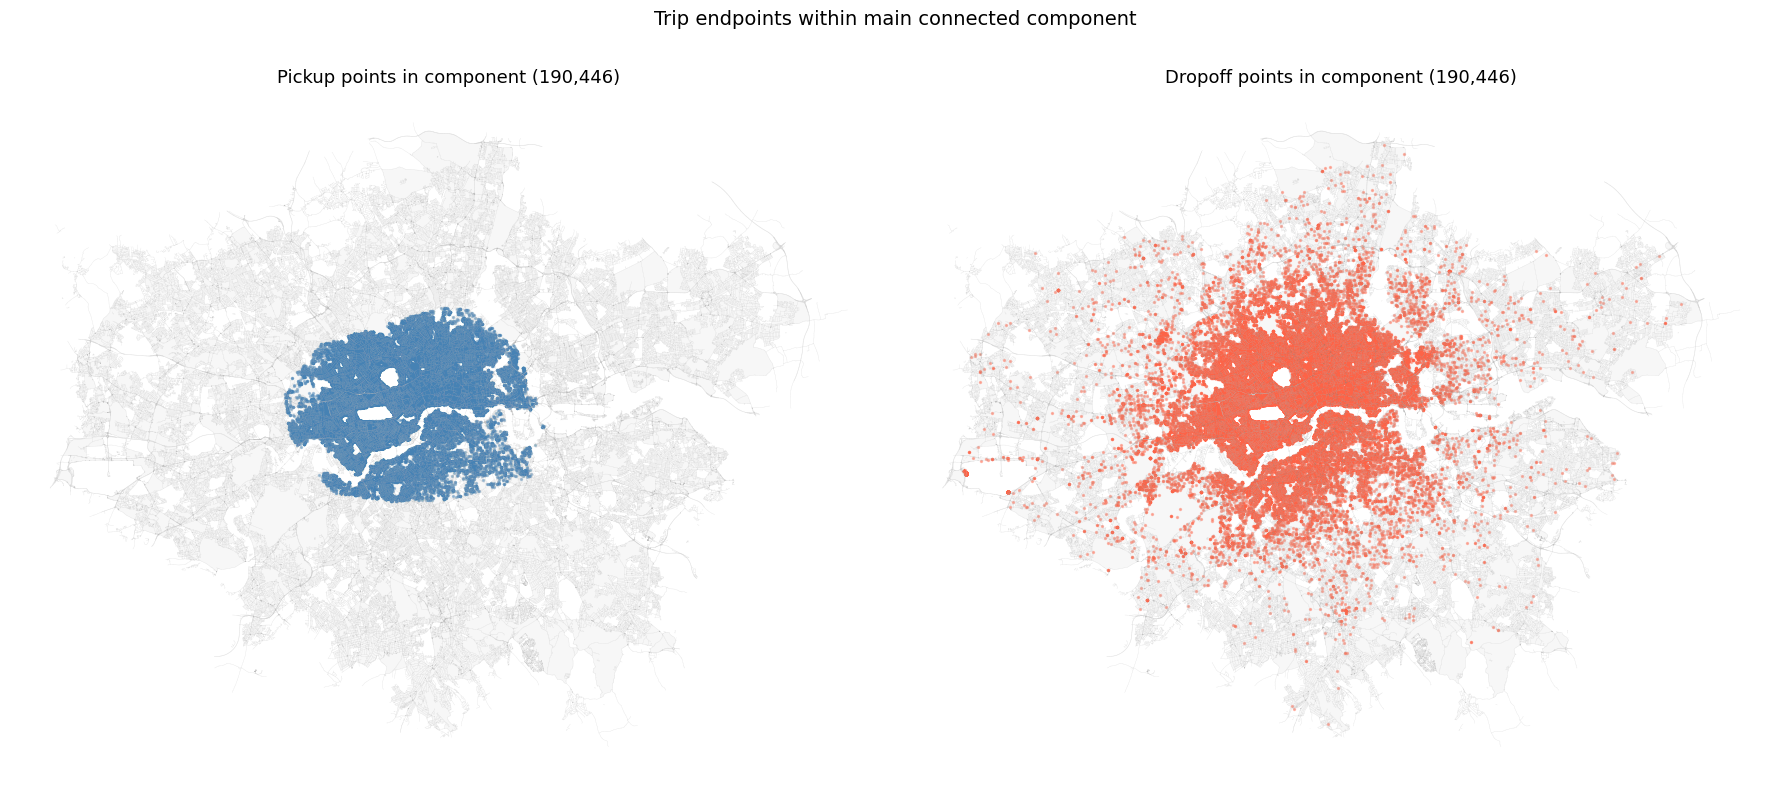

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, pts, color, title in [
    (axes[0], pickup_in,  'steelblue', f'Pickup points in component ({len(pickup_in):,})'),
    (axes[1], dropoff_in, 'tomato',    f'Dropoff points in component ({len(dropoff_in):,})'),
]:
    blocks_main.plot(ax=ax, color='whitesmoke', edgecolor='none', alpha=0.8)
    roads.plot(ax=ax, linewidth=0.2, color='silver', alpha=0.5)
    pts.plot(ax=ax, markersize=2, alpha=0.4, color=color)
    main_hull.plot(ax=ax, alpha=0, edgecolor='darkgreen', linewidth=1.5)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

plt.suptitle('Trip endpoints within main connected component', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Snap Points to Nearest Road

In [8]:
pickup_snapped  = snap_to_road(pickup_in,  roads, max_distance_m=100.0)
dropoff_snapped = snap_to_road(dropoff_in, roads, max_distance_m=100.0)

n_pickup_moved  = (pickup_in.geometry  != pickup_snapped.geometry).sum()
n_dropoff_moved = (dropoff_in.geometry != dropoff_snapped.geometry).sum()
print(f"Pickup  points snapped: {n_pickup_moved:,} / {len(pickup_in):,}")
print(f"Dropoff points snapped: {n_dropoff_moved:,} / {len(dropoff_in):,}")

# Write snapped coordinates back into trips_in as new columns.
# Convert from EPSG:27700 (metres) back to WGS-84 (degrees) for lat/lon.
pickup_wgs  = pickup_snapped.to_crs('EPSG:4326')
dropoff_wgs = dropoff_snapped.to_crs('EPSG:4326')

trips_in['pickup_lat_snapped']  = pickup_wgs.geometry.y.values
trips_in['pickup_lon_snapped']  = pickup_wgs.geometry.x.values
trips_in['dropoff_lat_snapped'] = dropoff_wgs.geometry.y.values
trips_in['dropoff_lon_snapped'] = dropoff_wgs.geometry.x.values

trips_in.head()

Pickup  points snapped: 187,787 / 190,446
Dropoff points snapped: 183,290 / 190,446


,quote_id,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,sampled_revenue,estimated_travel_time,pickup_lat_snapped,pickup_lon_snapped,dropoff_lat_snapped,dropoff_lon_snapped
0,OWI5NDU3NT,51.513,-0.1706,51.510,-0.150,13.67,428,51.513014,-0.170603,51.509885,-0.149945
1,NTQ1MGZhOD,51.496,-0.1990,51.510,-0.151,30.11,1208,51.496062,-0.198695,51.510167,-0.151083
2,NTY1NzQ0ZD,51.498,-0.1870,51.526,-0.279,33.17,1406,51.497838,-0.187005,51.526634,-0.278974
3,ZWE1NzNkOD,51.498,-0.1990,51.508,-0.135,30.17,1833,51.497944,-0.198916,51.507876,-0.135042
4,ZjRkM2NlYW,51.507,-0.1330,51.517,-0.096,29.28,1252,51.506975,-0.132977,51.517452,-0.095984


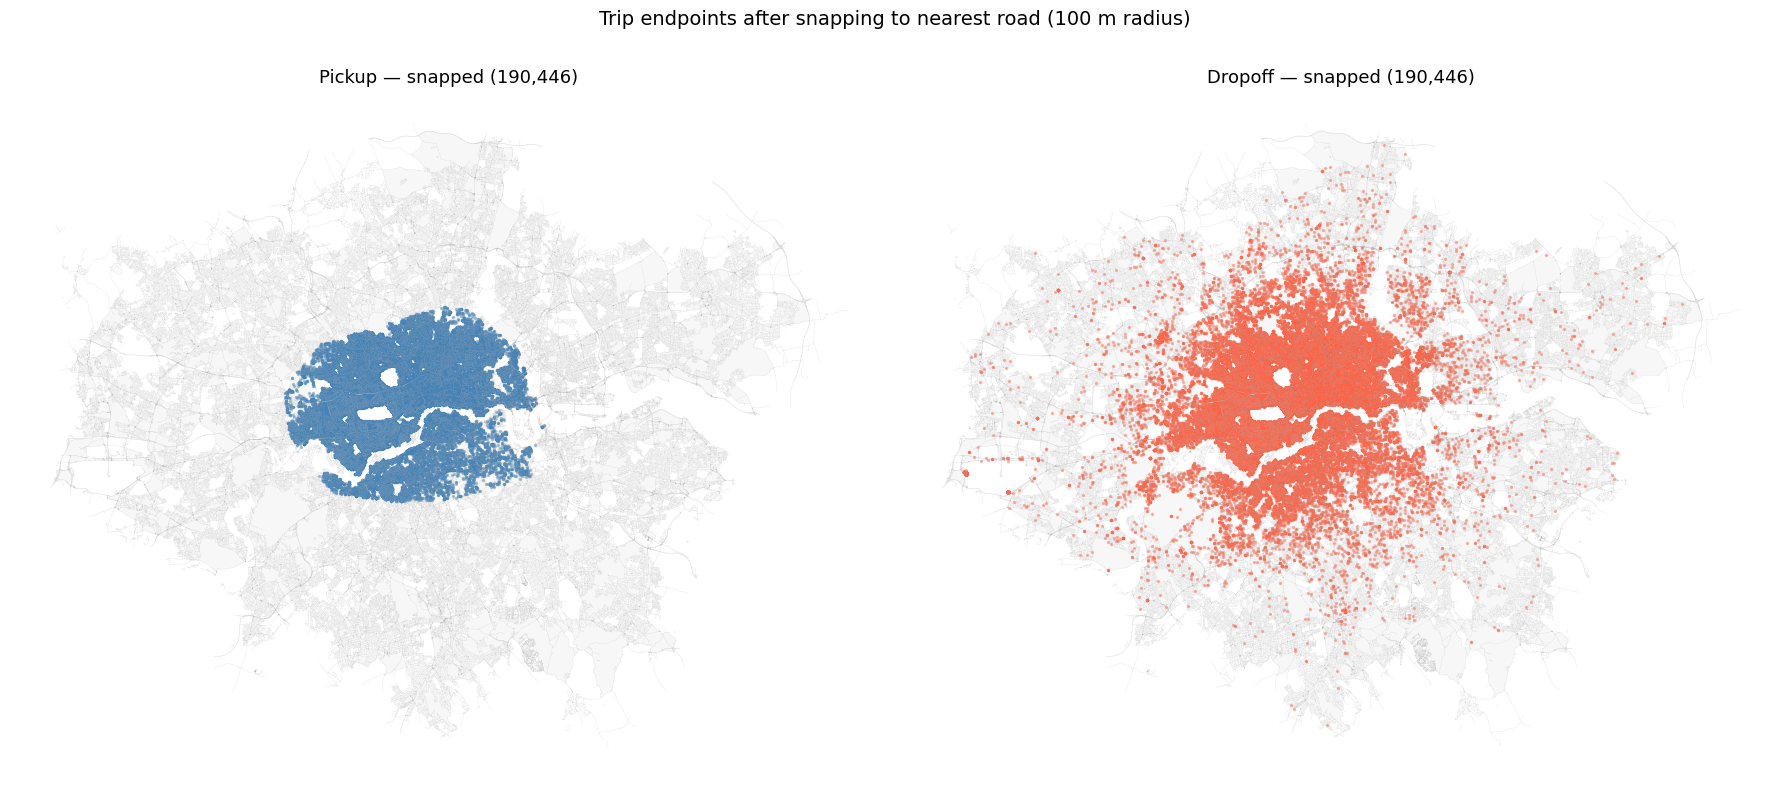

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, pts, color, title in [
    (axes[0], pickup_snapped,  'steelblue', f'Pickup — snapped ({len(pickup_snapped):,})'),
    (axes[1], dropoff_snapped, 'tomato',    f'Dropoff — snapped ({len(dropoff_snapped):,})'),
]:
    blocks_main.plot(ax=ax, color='whitesmoke', edgecolor='none', alpha=0.8)
    roads.plot(ax=ax, linewidth=0.2, color='silver', alpha=0.5)
    pts.plot(ax=ax, markersize=2, alpha=0.4, color=color)
    main_hull.plot(ax=ax, alpha=0, edgecolor='darkgreen', linewidth=1.5)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

plt.suptitle('Trip endpoints after snapping to nearest road (100 m radius)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Assign Points to Blocks

In [ ]:
# assign_to_blocks filters by hull internally (Step 0) then snaps to nearest road
# and falls back to nearest block centroid — guaranteeing 100 % assignment for
trips_assigned = assign_to_blocks(
    trips_in, blocks_main, roads, main_hull,
    snap_distance_m=cfg.SNAP_DISTANCE_M,
)
trips_assigned[['quote_id', 'sampled_revenue',
                'pickup_block', 'dropoff_block']].head(10)

Trips within main component: 190,446 / 190,446 (100.0 %)
Building road-block adjacency table...


  Road-block pairs: 345,873
Assigning pickup points...


  pickup: road-snapped=187,787  fallback=2,659  total=190,446
Assigning dropoff points...


  dropoff: road-snapped=183,290  fallback=7,156  total=190,446

Fully assigned trips: 190,446 / 190,446


,quote_id,sampled_revenue,pickup_block,dropoff_block
0,OWI5NDU3NT,13.67,7429,4776
1,NTQ1MGZhOD,30.11,16132,4776
2,NTY1NzQ0ZD,33.17,16684,11789
3,ZWE1NzNkOD,30.17,25890,7340
4,ZjRkM2NlYW,29.28,27172,25446
5,Mjc2MTI3ZG,21.11,4830,10062
6,NDk5ZjQ5NG,13.48,6856,7587
7,YmQyYTM5NG,19.83,16250,25055
8,ZTFiMmI3ZW,8.57,9019,15525
9,OTlkMDNjMT,16.29,16302,4013


In [ ]:
trips_assigned[["quote_id", "sampled_revenue",
                "pickup_block", "dropoff_block"]].to_csv(
    cfg.TRIPS_ASSIGNED_FILE, index=False
)
print(f"Saved trips_assigned.csv  ({len(trips_assigned):,} rows)")

Saved trips_assigned.csv  (190,446 rows)
